In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

# Chargement
data_frame = pd.read_csv('/Users/bakarybengaly/Documents/AnalyseventesB2B/dataset techsales360.csv')

# Nettoyage
data_frame['date_transaction'] = pd.to_datetime(data_frame['date_transaction'])
data_frame['campagne_marketing'] = data_frame['campagne_marketing'].fillna('Aucune')
data_frame['marge_eur'] = data_frame['montant_net_eur'] - data_frame['cout_acquisition_eur']
data_frame['annee'] = data_frame['date_transaction'].dt.year
data_frame['mois'] = data_frame['date_transaction'].dt.month
data_frame['roi_pct'] = data_frame.apply(
    lambda row: round((row['marge_eur'] / row['cout_acquisition_eur']) * 100, 2)
    if row['cout_acquisition_eur'] > 0 else 0, axis=1)

#on exclus l'année 2024 car on a pas les données de toute l'année et cela peut causer un problème 
data_frame = data_frame[data_frame['annee'] < 2024]

def get_saison(mois):
    if mois in [12, 1, 2]: return 'Hiver'
    elif mois in [3, 4, 5]: return 'Printemps'
    elif mois in [6, 7, 8]: return 'Ete'
    else: return 'Automne'

data_frame['saison'] = data_frame['mois'].apply(get_saison)

colonnes_a_supprimer = ['transaction_id', 'client_id', 'commercial_id',
                        'date_transaction', 'ville', 'statut_renouvellement']
data_frame = data_frame.drop(columns=colonnes_a_supprimer)

colonnes_texte = data_frame.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in colonnes_texte:
    data_frame[col] = le.fit_transform(data_frame[col])

data_frame = data_frame.replace([np.inf, -np.inf], np.nan).fillna(0)

df_majorite = data_frame[data_frame['churn'] == 0]
df_minorite = data_frame[data_frame['churn'] == 1]
df_minorite_augmente = resample(df_minorite, replace=True,
                                n_samples=len(df_majorite), random_state=42)
data_frame_equilivre = pd.concat([df_majorite, df_minorite_augmente])

X = data_frame_equilivre.drop(columns=['churn'])
y = data_frame_equilivre['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Données prêtes pour le Machine Learning ✅")

Données prêtes pour le Machine Learning ✅


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement des 3 modèles
modele_lr  = LogisticRegression(random_state=42, max_iter=1000)
modele_rf  = RandomForestClassifier(n_estimators=100, random_state=42)
modele_gb  = GradientBoostingClassifier(n_estimators=100, random_state=42)

modele_lr.fit(X_train, y_train)
modele_rf.fit(X_train, y_train)
modele_gb.fit(X_train, y_train)

print("Modèles entraînés ✅")

# Prédictions
pred_lr = modele_lr.predict(X_test)
pred_rf = modele_rf.predict(X_test)
pred_gb = modele_gb.predict(X_test)

# Scores AUC
auc_lr = roc_auc_score(y_test, modele_lr.predict_proba(X_test)[:,1])
auc_rf = roc_auc_score(y_test, modele_rf.predict_proba(X_test)[:,1])
auc_gb = roc_auc_score(y_test, modele_gb.predict_proba(X_test)[:,1])

print(f"\n=== SCORES AUC ===")
print(f"Régression Logistique : {auc_lr:.4f}")
print(f"Random Forest         : {auc_rf:.4f}")
print(f"Gradient Boosting     : {auc_gb:.4f}")

Modèles entraînés ✅

=== SCORES AUC ===
Régression Logistique : 0.6902
Random Forest         : 1.0000
Gradient Boosting     : 0.8978


In [3]:
from sklearn.metrics import classification_report

# Rapport détaillé du meilleur modèle
print("=== RAPPORT GRADIENT BOOSTING ===\n")
print(classification_report(y_test, pred_gb,
      target_names=['Non Churn', 'Churn']))

=== RAPPORT GRADIENT BOOSTING ===

              precision    recall  f1-score   support

   Non Churn       0.86      0.76      0.80       919
       Churn       0.78      0.87      0.83       927

    accuracy                           0.82      1846
   macro avg       0.82      0.82      0.82      1846
weighted avg       0.82      0.82      0.82      1846



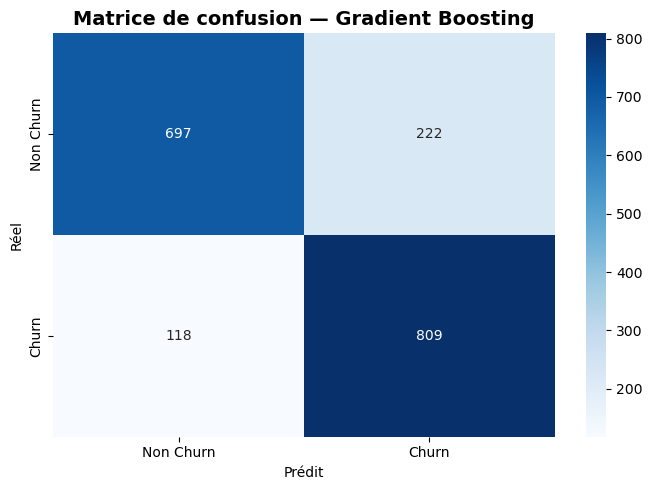

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matrice de confusion
cm = confusion_matrix(y_test, pred_gb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churn', 'Churn'],
            yticklabels=['Non Churn', 'Churn'])

plt.title("Matrice de confusion — Gradient Boosting", fontsize=14, fontweight='bold')
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()